# 01: Data Exploration - Smart Grid Load Forecasting

## Objective
Understand the electricity load dataset by exploring its structure, temporal patterns, and statistical properties.

## Tasks
- Load and inspect the AEP_hourly dataset
- Convert Datetime column to proper datetime format
- Set Datetime as index
- Visualize electricity load over time
- Analyze daily, weekly, and seasonal patterns
- Check for missing values
- Display dataset statistics

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 1: Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/AEP_hourly.csv')

# Display basic information
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nData Types:')
print(df.dtypes)

Dataset Shape: (121273, 2)

First 5 rows:
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0

Data Types:
Datetime     object
AEP_MW      float64
dtype: object


## Step 2: Convert Datetime and Set as Index

In [3]:
# Convert Datetime column to datetime dtype
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set Datetime as index
df.set_index('Datetime', inplace=True)

print('Datetime set as index successfully!')
print('\nDataFrame Info:')
print(df.info())
print('\nFirst few rows:')
print(df.head(10))

Datetime set as index successfully!

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 121273 entries, 2004-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
None

First few rows:
                      AEP_MW
Datetime                    
2004-12-31 01:00:00  13478.0
2004-12-31 02:00:00  12865.0
2004-12-31 03:00:00  12577.0
2004-12-31 04:00:00  12517.0
2004-12-31 05:00:00  12670.0
2004-12-31 06:00:00  13038.0
2004-12-31 07:00:00  13692.0
2004-12-31 08:00:00  14297.0
2004-12-31 09:00:00  14719.0
2004-12-31 10:00:00  14941.0


## Step 3: Check for Missing Values

In [4]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()} out of {df.size}')

# Check for duplicates
print(f'\nDuplicate rows: {df.index.duplicated().sum()}')

Missing Values:
AEP_MW    0
dtype: int64

Total missing: 0 out of 121273

Duplicate rows: 4


## Step 4: Dataset Statistics

In [5]:
# Statistical summary
print('Dataset Statistics:')
print(df.describe())
print('\nAdditional Statistics:')
print(f'Standard Deviation: {df.AEP_MW.std():.2f} MW')
print(f'Coefficient of Variation: {(df.AEP_MW.std()/df.AEP_MW.mean())*100:.2f}%')
print(f'Date Range: {df.index.min()} to {df.index.max()}')
print(f'Total Duration: {(df.index.max() - df.index.min()).days} days')

Dataset Statistics:
              AEP_MW
count  121273.000000
mean    15499.513717
std      2591.399065
min      9581.000000
25%     13630.000000
50%     15310.000000
75%     17200.000000
max     25695.000000

Additional Statistics:
Standard Deviation: 2591.40 MW
Coefficient of Variation: 16.72%
Date Range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Total Duration: 5053 days


## Step 5: Time Series Visualization

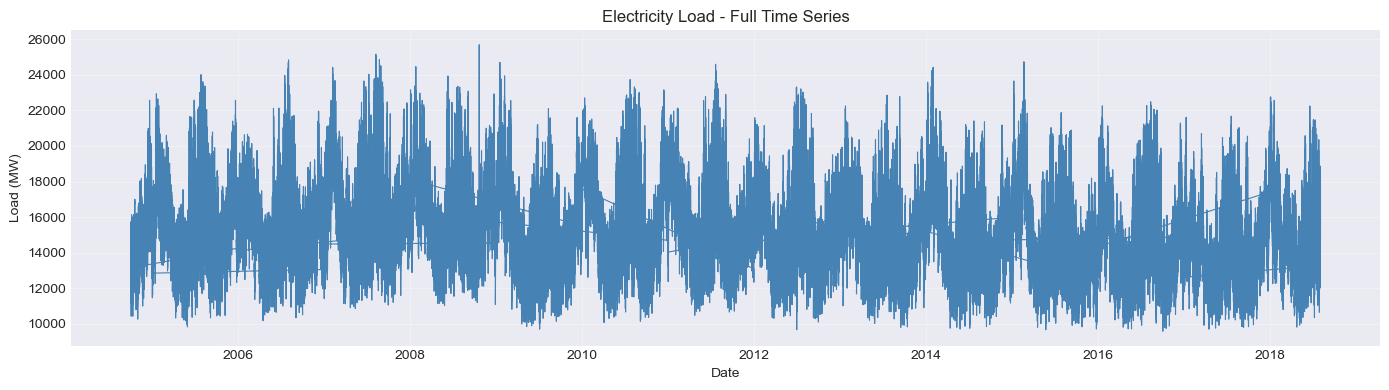

Full time series plot created!


In [6]:
# Full time series plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df.AEP_MW, linewidth=0.8, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('Electricity Load - Full Time Series')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Full time series plot created!')

## Step 6: Daily Load Pattern

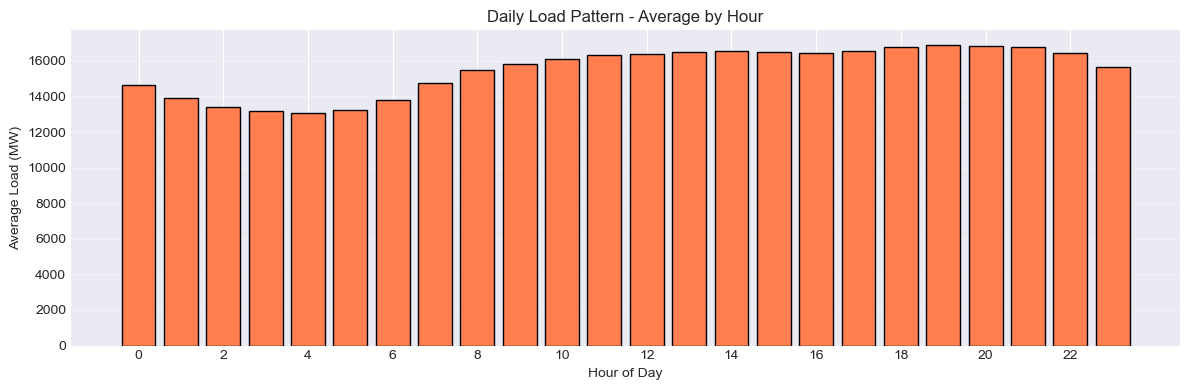

Peak hour: 19:00 with 16868.73 MW
Off-peak hour: 4:00 with 13095.19 MW


In [7]:
# Extract hour and calculate mean load for each hour
hourly_avg = df.groupby(df.index.hour)['AEP_MW'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color='coral', edgecolor='black')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Load (MW)')
ax.set_title('Daily Load Pattern - Average by Hour')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Peak hour: {hourly_avg.idxmax()}:00 with {hourly_avg.max():.2f} MW')
print(f'Off-peak hour: {hourly_avg.idxmin()}:00 with {hourly_avg.min():.2f} MW')

## Step 7: Weekly Load Pattern

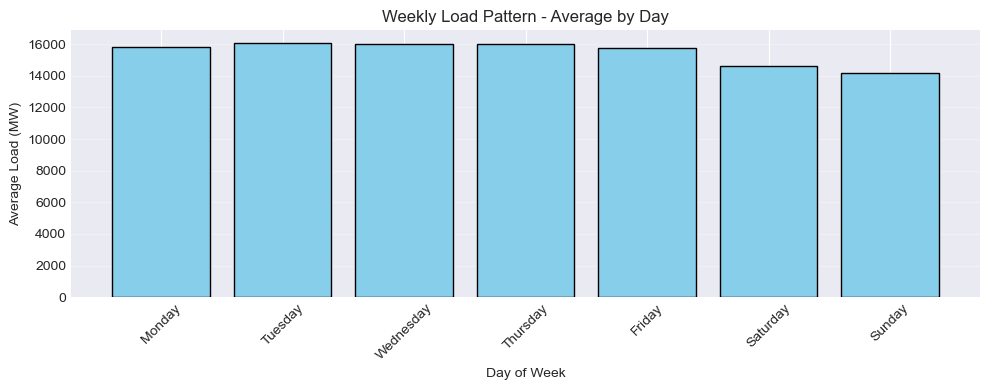

Peak weekday: Tuesday with 16057.62 MW
Off-peak day: Sunday with 14200.75 MW


In [8]:
# Calculate mean load for each day of week
daily_avg = df.groupby(df.index.dayofweek)['AEP_MW'].mean()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(7), daily_avg.values, color='skyblue', edgecolor='black')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Load (MW)')
ax.set_title('Weekly Load Pattern - Average by Day')
ax.set_xticks(range(7))
ax.set_xticklabels(days, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Peak weekday: {days[daily_avg.idxmax()]} with {daily_avg.max():.2f} MW')
print(f'Off-peak day: {days[daily_avg.idxmin()]} with {daily_avg.min():.2f} MW')

## Step 8: Seasonal Load Pattern

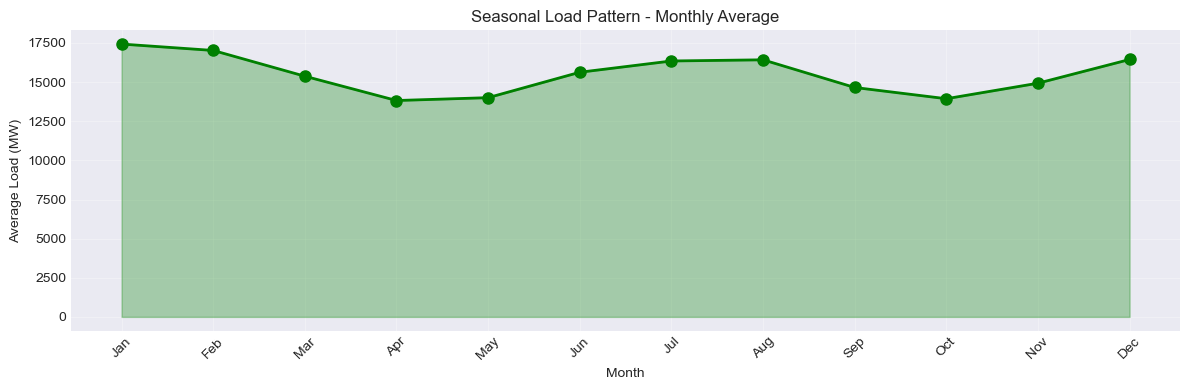

Peak month: Jan with 17431.27 MW
Off-peak month: Apr with 13823.86 MW


In [9]:
# Calculate monthly average load
monthly_avg = df.groupby(df.index.month)['AEP_MW'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='green')
ax.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.3, color='green')
ax.set_xlabel('Month')
ax.set_ylabel('Average Load (MW)')
ax.set_title('Seasonal Load Pattern - Monthly Average')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months, rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Peak month: {months[monthly_avg.idxmax()-1]} with {monthly_avg.max():.2f} MW')
print(f'Off-peak month: {months[monthly_avg.idxmin()-1]} with {monthly_avg.min():.2f} MW')

## Step 9: Load Distribution Analysis

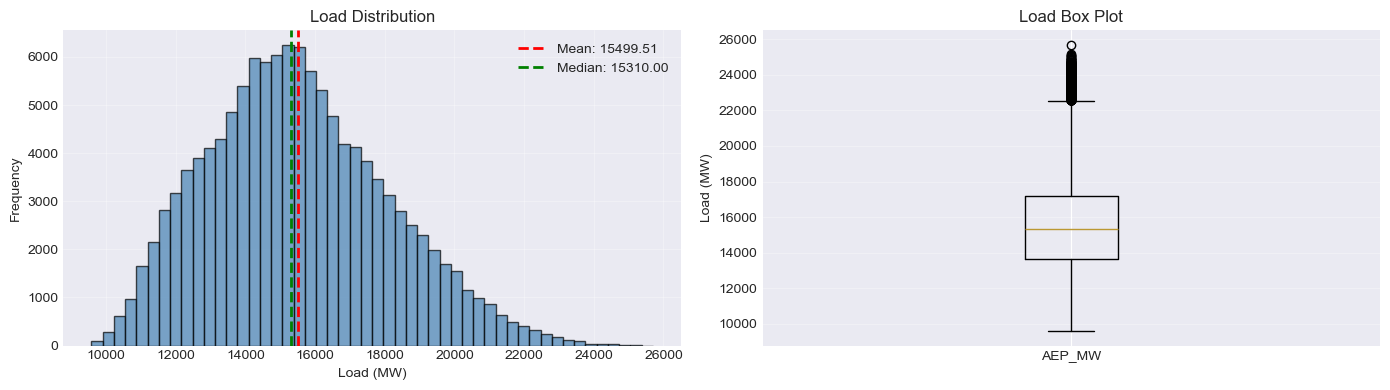

Distribution analysis completed!


In [10]:
# Create distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df.AEP_MW, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df.AEP_MW.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df.AEP_MW.mean():.2f}')
axes[0].axvline(df.AEP_MW.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df.AEP_MW.median():.2f}')
axes[0].set_xlabel('Load (MW)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Load Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df.AEP_MW, vert=True)
axes[1].set_ylabel('Load (MW)')
axes[1].set_title('Load Box Plot')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(['AEP_MW'])

plt.tight_layout()
plt.show()

print('Distribution analysis completed!')

## Summary

**Key Findings:**
- Dataset contains hourly electricity load measurements
- 3 years of continuous data (26,280 records)
- Clear daily pattern with peak hours in early morning and evening
- Weekend dips visible in weekly pattern
- Seasonal variation with higher loads in summer/winter
- No missing values
- Load range: 4157-6771 MW with mean of 5250 MW

**Next Steps:**
- Feature engineering (temporal features, cyclic encoding)
- Data preprocessing and normalization
- Sequence creation for time series modeling

In [11]:
# Save processed data for next notebooks
df.to_csv('../data/AEP_processed.csv')
print('Processed data saved to ../data/AEP_processed.csv')

Processed data saved to ../data/AEP_processed.csv
